# Import Required Libraries

In [22]:
import sys
import copy
from datetime import datetime
from pathlib import Path
import getpass
import copy
import pandas as pd
import numpy as np
import json
import pickle
import re
import os
import glob
from typing import Dict, List, Optional, Any, Tuple
from tqdm.notebook import tqdm
import time
import duckdb
import uuid
import glob

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from IPython.display import display, HTML
import ipywidgets as widgets
from ipywidgets import Output

# Import additional functions for atlas support
sys.path.append('/Users/BKieft/Metabolomics/metatlas2')
import metatlas2.targeted_analysis as ta
import metatlas2.database_interact as dbi

pd.options.display.max_colwidth = 300

# Configuration Settings

In [2]:
# Project setup
DATA_DIR = Path("/Users/BKieft/Metabolomics/metatlas2/data/")
DATABASES_DIR = DATA_DIR / "databases"
PROJECT = "20250707_JGI_MS_510172_SedRhizVegOut_final_IQX_HILICZ_USHXG02519"
PROJECT_DIR = DATA_DIR / "test_data/projects" / PROJECT

# Database Configuration - Using DuckDB atlas system
METATLAS_DB_PATH = DATABASES_DIR / "compounds/metatlas.duckdb"  # Main database
PROJECT_DB_PATH = PROJECT_DIR / f"{PROJECT}.duckdb"  # Project-specific database
MSMS_REFS_PATH = DATABASES_DIR / "msms_refs/msms_refs.tab"

# Atlas Configuration - Using RT-corrected atlas from project database
TARGET_ATLAS_UID = "atlas-rt-f07d3fb1335e4f4ab85f8d35c765df4a"

# Analysis Parameters
DEFAULT_MZ_TOLERANCE_PPM = 5.0  # Default m/z tolerance in ppm
USE_ATLAS_MZ_TOLERANCE = True   # Use mz_tolerance from Atlas if available
RT_WINDOW_EXPANSION = 0         # Extra RT window (minutes) around corrected RT for peak search
MIN_PEAK_INTENSITY = 1e5        # Minimum peak intensity for consideration

# Output Configuration
OUTPUT_DIR = DATA_DIR / "targeted_results/"
TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")
EXPORT_FORMATS = ['csv', 'json']  # Export formats
INCLUDE_PLOTS = True              # Generate summary plots
ANALYST_NAME = getpass.getuser()

# Create output directory
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Configuration set:")
print(f"  Main database: {METATLAS_DB_PATH}")
print(f"  Project database: {PROJECT_DB_PATH}")
print(f"  Output directory: {OUTPUT_DIR}")
print(f"  Default m/z tolerance: {DEFAULT_MZ_TOLERANCE_PPM} ppm")
print(f"  RT search window: ±{RT_WINDOW_EXPANSION} min")
print(f"  Analyst: {ANALYST_NAME}")
print(f"  Timestamp: {TIMESTAMP}")

Configuration set:
  Main database: /Users/BKieft/Metabolomics/metatlas2/data/databases/compounds/metatlas.duckdb
  Project database: /Users/BKieft/Metabolomics/metatlas2/data/test_data/projects/20250707_JGI_MS_510172_SedRhizVegOut_final_IQX_HILICZ_USHXG02519/20250707_JGI_MS_510172_SedRhizVegOut_final_IQX_HILICZ_USHXG02519.duckdb
  Output directory: /Users/BKieft/Metabolomics/metatlas2/data/targeted_results
  Default m/z tolerance: 5.0 ppm
  RT search window: ±0 min
  Analyst: BKieft
  Timestamp: 20250827_134736


In [3]:
try: 
    atlas_df_ft, eics, ms2_data_with_hits, ms2_hits = ta.run_targeted_analysis_workflow( 
        project_db_path=str(PROJECT_DB_PATH), 
        main_db_path=str(METATLAS_DB_PATH), 
        target_atlas_uid=TARGET_ATLAS_UID, 
        msms_refs_path=str(MSMS_REFS_PATH), 
        default_mz_tolerance=DEFAULT_MZ_TOLERANCE_PPM, 
        rt_window_expansion=RT_WINDOW_EXPANSION 
    )
    print("\nWorkflow completed successfully!")
except Exception as e:
    print(f"Error in workflow: {e}")

Setting up targeted analysis database...
Created targeted_analysis table in project database
Loading target atlas...
Retrieved 65 compounds from project database for atlas: HILIC Positive ISTD Default (RT Corrected)
Atlas chromatography: HILICZ, polarity: positive
RT-corrected atlas detected with experimental data
Enriched 65 compounds with metadata from main database
Created Atlas dataframe with 65 compounds
Loading experimental files from project database...
Found 5 experimental files in database
Found 5 experimental files
Preparing inputs for feature extraction...
Created 5 input dictionaries
Extracting EIC and MS2 data...
Extracting enhanced EIC and MS2 data from 5 files...
Using metadata for 65 compounds from atlas...


Processing enhanced data:   0%|          | 0/5 [00:00<?, ?it/s]

  1/5: 20250707_JGI_MS_510172_SedRhizVegOut_final_IQX_HILICZ_USHXG02519_FPS_MS1_28_Spring-VSp_2_Rg70to1050-CE102040norm-veg-core-ISTD_Run31.h5 -> EIC data extracted (51 compounds)
    MS2: No data found
  2/5: 20250707_JGI_MS_510172_SedRhizVegOut_final_IQX_HILICZ_USHXG02519_POS_MS2_36_Fall-VFa_7_Rg70to1050-CE102040norm-veg-core-S1_Run136.h5 -> EIC data extracted (55 compounds)
    MS2 summary: 129 spectra
  3/5: 20250707_JGI_MS_510172_SedRhizVegOut_final_IQX_HILICZ_USHXG02519_POS_MS2_48_Fall-BFa_7_Rg70to1050-CE102040norm-nonveg-core-S1_Run127.h5 -> EIC data extracted (58 compounds)
    MS2 summary: 120 spectra
  4/5: 20250707_JGI_MS_510172_SedRhizVegOut_final_IQX_HILICZ_USHXG02519_POS_MS2_54_ExCtrl_6_Rg70to1050-CE102040norm-ExCtrl-S1_Run102.h5 -> EIC data extracted (51 compounds)
    MS2 summary: 92 spectra
  5/5: 20250707_JGI_MS_510172_SedRhizVegOut_final_IQX_HILICZ_USHXG02519_POS_MS2_9_Spring-RSp_6_Rg70to1050-CE102040norm-rhizo-S1_Run99.h5 -> EIC data extracted (47 compounds)
    MS2

Processing MS2 files:   0%|          | 0/4 [00:00<?, ?it/s]

MS2 hits identified: 7888
Found 2595 high-quality matches

Workflow completed successfully!


=== MS2 Hits Analysis Results ===
Analysis Summary:
  total_spectra: 7888
  spectra_with_hits: 4044
  high_quality_matches: 2838
  mean_score: 0.3004516411660871
  median_score: 0.001334899874061261

=== Score Distribution ===


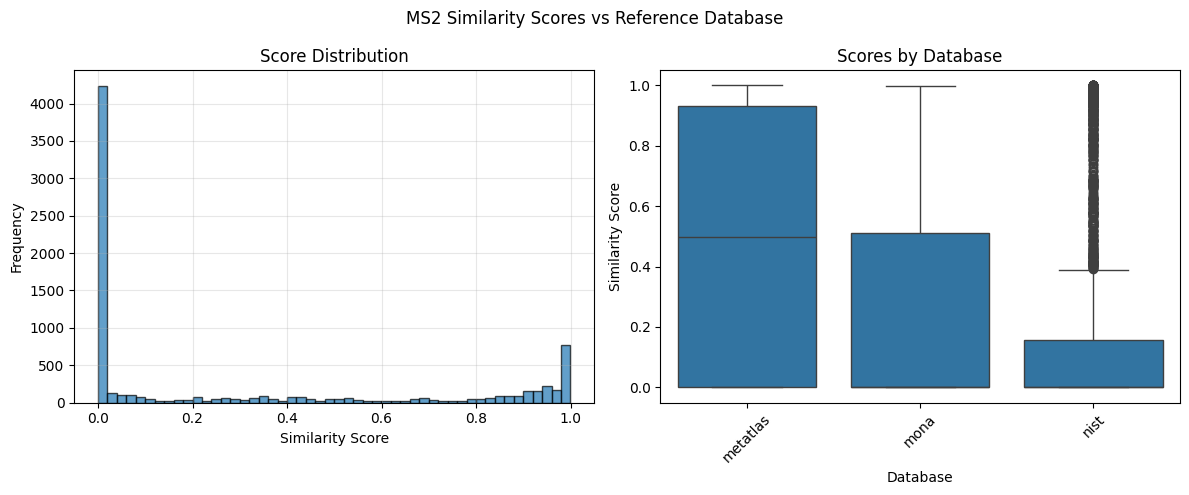

Score statistics:
  Mean: 0.300
  Median: 0.001
  Min: 0.000
  Max: 1.000
  Total hits: 7888

=== High-Quality Matches (Score >= 0.4, Matches >= 2) ===
Found 2595 high-quality matches
Unique compounds with high-quality matches: 34


In [4]:
if not ms2_hits.empty:
    print("=== MS2 Hits Analysis Results ===")

    # Analyze the results
    analysis = ta.analyze_ms2_hits_results(ms2_hits, min_score=0.3, min_matches=2)

    print(f"Analysis Summary:")
    for key, value in analysis.items():
        print(f"  {key}: {value}")

    # Plot score distribution
    print(f"\n=== Score Distribution ===")
    ta.plot_ms2_score_distribution(ms2_hits, "MS2 Similarity Scores vs Reference Database")

    # Show high-quality matches summary
    print(f"\n=== High-Quality Matches (Score >= 0.4, Matches >= 2) ===")
    high_quality_hits = ta.filter_ms2_hits(ms2_hits, min_score=0.4, min_matches=2)

    if not high_quality_hits.empty:
        print(f"Found {len(high_quality_hits)} high-quality matches")
        print(f"Unique compounds with high-quality matches: {high_quality_hits['inchi_key'].nunique()}")
    else:
        print("No high-quality matches found")
else:
    print("No MS2 hits data available for analysis")

# Set up targeted plotter

In [5]:
plot_data = ta.set_up_plot_data(eics, atlas_df_ft, ms2_data_with_hits)

file_color_dict = {
    'ISTD': 'blue',
    'ExCtrl': 'red', 
    'InjBl': 'orange',
}

Building complete compound metadata dictionary...


Processing compounds:   0%|          | 0/65 [00:00<?, ?it/s]

In [6]:
gui = ta.create_gui(
    compound_metadata=plot_data,
    atlas_df=atlas_df_ft,
    file_color_dict=file_color_dict
)

display(gui)

In [20]:
plot_data['AGPKZVBTJJNPAG-WHFBIAKZSA-N']['new_atlas_data']

{'rt_min': 9.660743564660672,
 'rt_max': 10.000743564660672,
 'rt_peak': 9.830743564660672,
 'mz': 132.10191,
 'mz_tolerance': 10.0,
 'adduct': '[M+H]+',
 'polarity': 'positive',
 'compound_name': 'isoleucine',
 'inchi_key': 'AGPKZVBTJJNPAG-WHFBIAKZSA-N',
 'formula': 'C6H13NO2',
 'exact_mass': 131.094628657,
 'isomers': [{'inchi_key': 'ROHFNLRQFUQHCH-UHFFFAOYSA-N',
   'compound_name': 'leucine',
   'rt': 9.257794901473394,
   'mz': 132.10191,
   'tolerance': 10.0}],
 'ms2_notes': '1.0, good match',
 'ms1_notes': 'unresolvable isomers'}

In [23]:
dbi.validate_database(PROJECT_DB_PATH)


Database Validation:
   Compounds: 0
   RT/MZ References: 0
   Atlases: 1
   Atlas-Compound associations: 65
   No method combinations found
   Available atlases:
      atlas-rt-f07d3fb1335e4f4ab85f8d35c765df4a
            HILIC Positive ISTD Default (RT Corrected)
            HILICZ positive
            65 compounds
            2025-08-27 09:56:14.190029
